In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score

In [2]:
X, y = make_regression(n_samples=100, n_features=1, n_informative= 1 ,n_targets=1, noise=20)

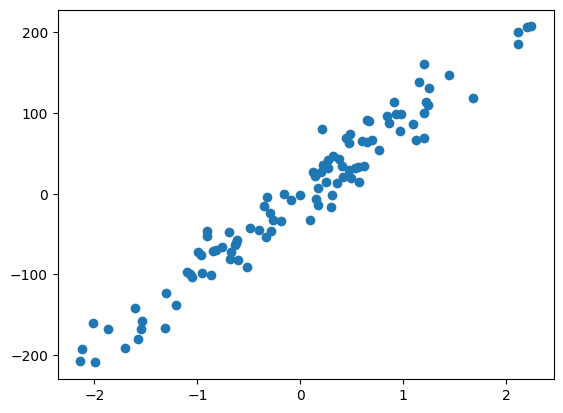

In [3]:
plt.scatter(X,y)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [5]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[93.5]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.402
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[9.14]


In [6]:
y_pred = lr.predict(X_test)

In [7]:
print(lr.coef_)
print(lr.intercept_)

[93.50356808]
-1.402456245846293


In [8]:
r2_score(y_test, y_pred)

0.9634125435449133

### Making own class for Gradient Descent:

In [9]:
class GDRegressor():
    def __init__(self, learnig_rate, epochs):
        self.m = 20
        self.b = -100
        self.lr = learnig_rate
        self.epochs = epochs

    def fit(self,X, y):

        for i in range(self.epochs):
            slope_at_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            slope_at_m = -2 * np.sum((y - self.m*X.ravel() - self.b) * X.ravel())

            self.b = self.b - (self.lr * slope_at_b)
            self.m = self.m - (self.lr * slope_at_m)
            
        print(self.m, self.b)

    def predict(self, X):
        return (self.m * X) + self.b

In [10]:
gd = GDRegressor(0.001, 50)

In [11]:
gd.fit(X_train, y_train)

93.50147879445105 -1.4153400370759235


In [12]:
gd.predict(X_test)

array([[-187.55662734],
       [ -26.33638122],
       [  17.01962206],
       [  43.26427803],
       [ -65.66166573],
       [ -99.52257829],
       [-124.68116976],
       [  85.51498948],
       [-113.9041406 ],
       [ -72.27097044],
       [  48.1446738 ],
       [-101.97273591],
       [  51.18014864],
       [  89.86829382],
       [ -77.99360344],
       [ -58.93639706],
       [ -65.77655018],
       [ 100.93758833],
       [  59.43226171],
       [  89.31614701]])

In [13]:
r2_score(y_test, y_pred)

0.9634125435449133

### Got help for the visualization code:
> **Note:** The animations below aren't rendered here to keep the notebook lightweight — `anim.to_jshtml()` embeds every frame as a base64 image, which can bloat the file size to 20MB+. Run the cells locally to view them.

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

class GDRegressor():
    def __init__(self, learnig_rate, epochs):
        self.m = 20
        self.b = -100
        self.lr = learnig_rate
        self.epochs = epochs
        self.history = []  # track (m, b, cost) per epoch

    def fit(self, X, y):
        X = X.ravel()
        for i in range(self.epochs):
            y_pred = self.m * X + self.b
            cost = np.mean((y - y_pred) ** 2)
            self.history.append((self.m, self.b, cost))

            slope_at_b = -2 * np.sum(y - self.m * X - self.b)
            slope_at_m = -2 * np.sum((y - self.m * X - self.b) * X)

            self.b = self.b - (self.lr * slope_at_b)
            self.m = self.m - (self.lr * slope_at_m)

        y_pred_final = self.m * X + self.b
        cost_final = np.mean((y - y_pred_final) ** 2)
        self.history.append((self.m, self.b, cost_final))

    def predict(self, X):
        return (self.m * X) + self.b


gd = GDRegressor(0.001, 60)
gd.fit(X_train, y_train)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_line = np.linspace(X_train.min(), X_train.max(), 100)
ax1.scatter(X_train, y_train, color='#378ADD', s=20)
line, = ax1.plot([], [], color='#D85A30', linewidth=2)
ax1.set_xlim(X_train.min() - 0.5, X_train.max() + 0.5)
ax1.set_ylim(y_train.min() - 20, y_train.max() + 20)
ax1.set_title('Fit')

costs = [h[2] for h in gd.history]
cost_line, = ax2.plot([], [], color='#7F77DD', linewidth=2)
ax2.set_xlim(0, len(gd.history))
ax2.set_ylim(0, max(costs) * 1.05)
ax2.set_xlabel('epoch')
ax2.set_title('Cost vs epoch')

def update(frame):
    m, b, cost = gd.history[frame]
    line.set_data(x_line, m * x_line + b)
    cost_line.set_data(range(frame + 1), costs[:frame + 1])
    return line, cost_line

anim = FuncAnimation(fig1, update, frames=len(gd.history), interval=100, blit=True)
plt.close(fig1)
display(HTML(anim.to_jshtml()))

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

X_flat = X_train.ravel()
y_flat = y_train

def cost(m, b):
    y_pred = m * X_flat + b
    return np.mean((y_flat - y_pred) ** 2)

m_hist = [h[0] for h in gd.history]
b_hist = [h[1] for h in gd.history]

m_range = np.linspace(min(m_hist) - 20, max(m_hist) + 20, 60)
b_range = np.linspace(min(b_hist) - 20, max(b_hist) + 20, 60)
M, B = np.meshgrid(m_range, b_range)

Z = np.zeros_like(M)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        Z[i, j] = cost(M[i, j], B[i, j])

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(M, B, Z, cmap='plasma', alpha=0.75, edgecolor='none')

path_costs = [h[2] for h in gd.history]
ax.plot(m_hist, b_hist, path_costs, color='blue', linewidth=2, marker='o', markersize=3)

ax.set_xlabel('m')
ax.set_ylabel('b')
ax.set_zlabel('Cost')
ax.set_title('Gradient Descent path on the cost surface')

def rotate(angle):
    ax.view_init(elev=25, azim=angle)
    return fig,

anim3d = FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=50)
plt.close(fig)
HTML(anim3d.to_jshtml())